0. Setup

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from skimage.metrics import structural_similarity as ssim
import time, warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
torch.manual_seed(42); np.random.seed(42)

Device: cuda


1. Dataset — Fashion-MNIST

Train: 60000 | Test: 10000


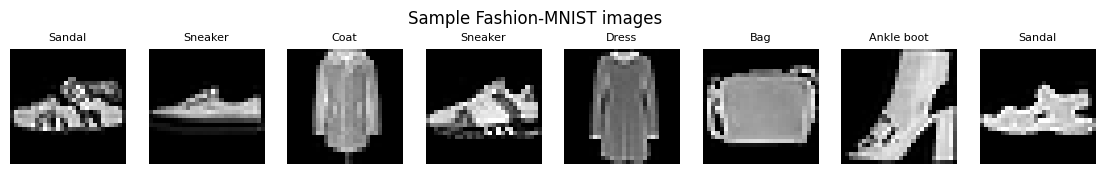

In [15]:
transform = transforms.ToTensor()   # -> [0,1], shape (1,28,28)

train_ds = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=transform)
test_ds  = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

CLASSES = ['T-shirt','Trouser','Pullover','Dress','Coat',
           'Sandal','Shirt','Sneaker','Bag','Ankle boot']

BATCH = 128
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256,  shuffle=False, num_workers=2, pin_memory=True)

print("Train:", len(train_ds), "| Test:", len(test_ds))

# Sanity check
x, y = next(iter(train_loader))
fig, ax = plt.subplots(1, 8, figsize=(14, 2))
for i in range(8):
    ax[i].imshow(x[i, 0], cmap="gray"); ax[i].set_title(CLASSES[y[i]], fontsize=8); ax[i].axis("off")
plt.suptitle("Sample Fashion-MNIST images"); plt.show()

2. Autoencoder (AE)

2.1 Architecture

In [16]:
class AEEncoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(),      # 28 -> 14
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),     # 14 -> 7
            nn.Conv2d(64, 128, 3, 2, 1), nn.ReLU(),    # 7  -> 4
        )
        self.fc = nn.Linear(128 * 4 * 4, latent_dim)

    def forward(self, x):
        return self.fc(self.conv(x).flatten(1))


class AEDecoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, 2, 1, output_padding=1), nn.ReLU(),  # 4  -> 8
            nn.ConvTranspose2d(64, 32, 2, 2, 1), nn.ReLU(),                     # 8  -> 14
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Sigmoid(),                   # 14 -> 28
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 128, 4, 4)
        return self.deconv(h)


class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = AEEncoder(latent_dim)
        self.decoder = AEDecoder(latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


LATENT_AE = 32
ae = Autoencoder(LATENT_AE).to(device)
print(ae)
print("AE params:", sum(p.numel() for p in ae.parameters()))

Autoencoder(
  (encoder): AEEncoder(
    (conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
    )
    (fc): Linear(in_features=2048, out_features=32, bias=True)
  )
  (decoder): AEDecoder(
    (fc): Linear(in_features=32, out_features=2048, bias=True)
    (deconv): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): Sigmoid()
    )
  )
)
AE params: 322913


2.2 Training

AE  epoch  1/20  recon_loss=22.1519  (9.2s)
AE  epoch  2/20  recon_loss=10.0624  (9.2s)
AE  epoch  3/20  recon_loss=8.3179  (8.6s)
AE  epoch  4/20  recon_loss=7.4679  (10.5s)
AE  epoch  5/20  recon_loss=6.9887  (9.5s)
AE  epoch  6/20  recon_loss=6.6567  (8.2s)
AE  epoch  7/20  recon_loss=6.4240  (9.4s)
AE  epoch  8/20  recon_loss=6.2450  (9.3s)
AE  epoch  9/20  recon_loss=6.0979  (8.8s)
AE  epoch 10/20  recon_loss=5.9843  (10.7s)
AE  epoch 11/20  recon_loss=5.8817  (9.7s)
AE  epoch 12/20  recon_loss=5.8009  (9.0s)
AE  epoch 13/20  recon_loss=5.7273  (8.7s)
AE  epoch 14/20  recon_loss=5.6650  (9.5s)
AE  epoch 15/20  recon_loss=5.6112  (9.5s)
AE  epoch 16/20  recon_loss=5.5685  (8.4s)
AE  epoch 17/20  recon_loss=5.5342  (9.4s)
AE  epoch 18/20  recon_loss=5.5071  (9.5s)
AE  epoch 19/20  recon_loss=5.4880  (8.4s)
AE  epoch 20/20  recon_loss=5.4766  (10.1s)


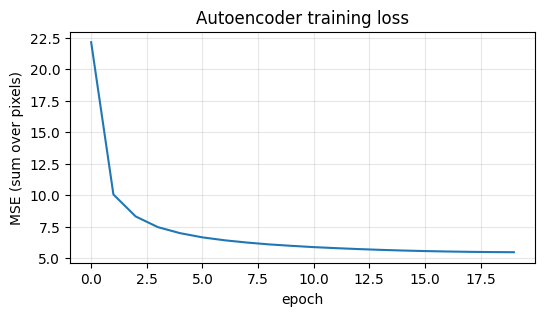

In [17]:
 def train_ae(model, loader, epochs=20, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    hist = []
    for ep in range(epochs):
        model.train(); total = 0.0; t0 = time.time()
        for x, _ in loader:
            x = x.to(device, non_blocking=True)
            opt.zero_grad()
            out, _ = model(x)
            loss = F.mse_loss(out, x, reduction="sum") / x.size(0)
            loss.backward(); opt.step()
            total += loss.item() * x.size(0)
        sched.step()
        avg = total / len(loader.dataset); hist.append(avg)
        print(f"AE  epoch {ep+1:2d}/{epochs}  recon_loss={avg:.4f}  ({time.time()-t0:.1f}s)")
    return hist

ae_hist = train_ae(ae, train_loader, epochs=20)

plt.figure(figsize=(6,3))
plt.plot(ae_hist); plt.xlabel("epoch"); plt.ylabel("MSE (sum over pixels)")
plt.title("Autoencoder training loss"); plt.grid(alpha=.3); plt.show()

2.3 Reconstruction samples

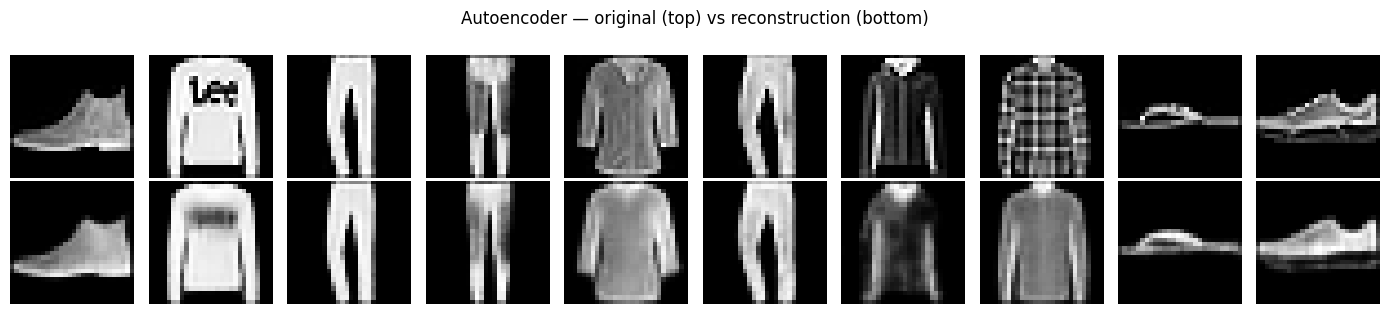

In [18]:
@torch.no_grad()
def show_reconstructions(model, loader, n=10, title="Reconstructions"):
    model.eval()
    x, _ = next(iter(loader)); x = x[:n].to(device)
    out, _ = model(x)
    out = out.cpu(); x = x.cpu()
    fig, ax = plt.subplots(2, n, figsize=(n*1.4, 3.2))
    for i in range(n):
        ax[0, i].imshow(x[i, 0], cmap="gray"); ax[0, i].axis("off")
        ax[1, i].imshow(out[i, 0], cmap="gray"); ax[1, i].axis("off")
    ax[0, 0].set_ylabel("Original", fontsize=10)
    ax[1, 0].set_ylabel("Recon", fontsize=10)
    plt.suptitle(title); plt.tight_layout(); plt.show()

show_reconstructions(ae, test_loader, n=10, title="Autoencoder — original (top) vs reconstruction (bottom)")

3. Variational Autoencoder (VAE)

3.1 Architecture + reparameterization trick

In [19]:
class VAEEncoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1), nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)

    def forward(self, x):
        h = self.conv(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)


class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim)
        self.decoder = AEDecoder(latent_dim)   # same decoder structure as AE
        self.latent_dim = latent_dim

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std              # z = mu + sigma * eps

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar, z

    @torch.no_grad()
    def sample(self, n, device):
        z = torch.randn(n, self.latent_dim, device=device)
        return self.decoder(z)


LATENT_VAE = 32
vae = VAE(LATENT_VAE).to(device)
print("VAE params:", sum(p.numel() for p in vae.parameters()))

VAE params: 388481


3.2 Training (reconstruction + KL divergence)

VAE epoch  1/20  total=41.93  recon=34.55  KL=7.38  (9.9s)
VAE epoch  2/20  total=27.83  recon=19.87  KL=7.96  (9.8s)
VAE epoch  3/20  total=26.75  recon=18.70  KL=8.05  (9.0s)
VAE epoch  4/20  total=26.18  recon=18.09  KL=8.09  (9.9s)
VAE epoch  5/20  total=25.76  recon=17.67  KL=8.09  (10.0s)
VAE epoch  6/20  total=25.46  recon=17.33  KL=8.13  (9.0s)
VAE epoch  7/20  total=25.23  recon=17.08  KL=8.15  (9.6s)
VAE epoch  8/20  total=25.02  recon=16.84  KL=8.18  (10.0s)
VAE epoch  9/20  total=24.86  recon=16.66  KL=8.20  (9.8s)
VAE epoch 10/20  total=24.71  recon=16.50  KL=8.21  (8.8s)
VAE epoch 11/20  total=24.61  recon=16.39  KL=8.21  (10.0s)
VAE epoch 12/20  total=24.48  recon=16.25  KL=8.22  (9.7s)
VAE epoch 13/20  total=24.37  recon=16.15  KL=8.22  (8.9s)
VAE epoch 14/20  total=24.31  recon=16.06  KL=8.24  (9.5s)
VAE epoch 15/20  total=24.21  recon=15.97  KL=8.25  (10.3s)
VAE epoch 16/20  total=24.15  recon=15.90  KL=8.25  (9.8s)
VAE epoch 17/20  total=24.11  recon=15.85  KL=8.25  

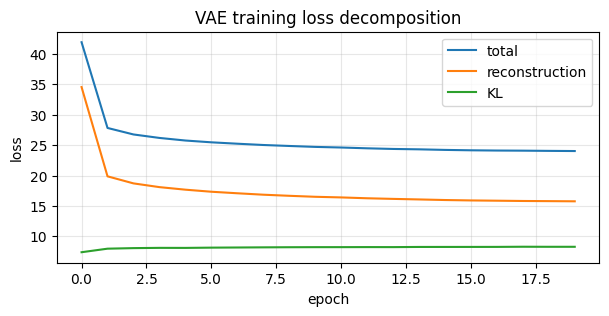

In [20]:
def vae_loss(recon, x, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(recon, x, reduction="sum") / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + beta * kl, recon_loss, kl


def train_vae(model, loader, epochs=20, lr=1e-3, beta=1.0):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    hist = {"total": [], "recon": [], "kl": []}
    for ep in range(epochs):
        model.train(); tot = rec = kld = 0.0; t0 = time.time()
        for x, _ in loader:
            x = x.to(device, non_blocking=True)
            opt.zero_grad()
            out, mu, logvar, _ = model(x)
            loss, r, k = vae_loss(out, x, mu, logvar, beta)
            loss.backward(); opt.step()
            tot += loss.item()*x.size(0); rec += r.item()*x.size(0); kld += k.item()*x.size(0)
        sched.step()
        n = len(loader.dataset)
        hist["total"].append(tot/n); hist["recon"].append(rec/n); hist["kl"].append(kld/n)
        print(f"VAE epoch {ep+1:2d}/{epochs}  total={tot/n:.2f}  recon={rec/n:.2f}  KL={kld/n:.2f}  ({time.time()-t0:.1f}s)")
    return hist

vae_hist = train_vae(vae, train_loader, epochs=20, beta=1.0)

plt.figure(figsize=(7,3))
plt.plot(vae_hist["total"], label="total")
plt.plot(vae_hist["recon"], label="reconstruction")
plt.plot(vae_hist["kl"], label="KL")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.grid(alpha=.3)
plt.title("VAE training loss decomposition"); plt.show()

3.3 VAE reconstructions & random samples

In [21]:
@torch.no_grad()
def show_reconstructions(model, loader, n=10, title="Reconstructions", kind="ae"):
    """
    kind='ae'  -> model(x) returns (recon, z)
    kind='vae' -> model(x) returns (recon, mu, logvar, z)
    """
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)

    out = model(x)
    recon = out[0]              # first element is always the reconstruction
    recon = recon.cpu()
    x = x.cpu()

    fig, ax = plt.subplots(2, n, figsize=(n * 1.4, 3.2))
    for i in range(n):
        ax[0, i].imshow(x[i, 0], cmap="gray");     ax[0, i].axis("off")
        ax[1, i].imshow(recon[i, 0], cmap="gray"); ax[1, i].axis("off")
    ax[0, 0].set_ylabel("Original", fontsize=10)
    ax[1, 0].set_ylabel("Recon", fontsize=10)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

4. Latent Space Analysis

4.1 t-SNE of latent codes (AE vs VAE)

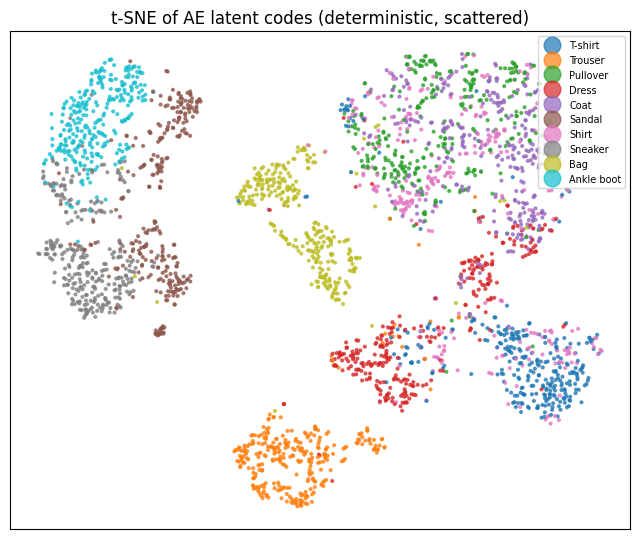

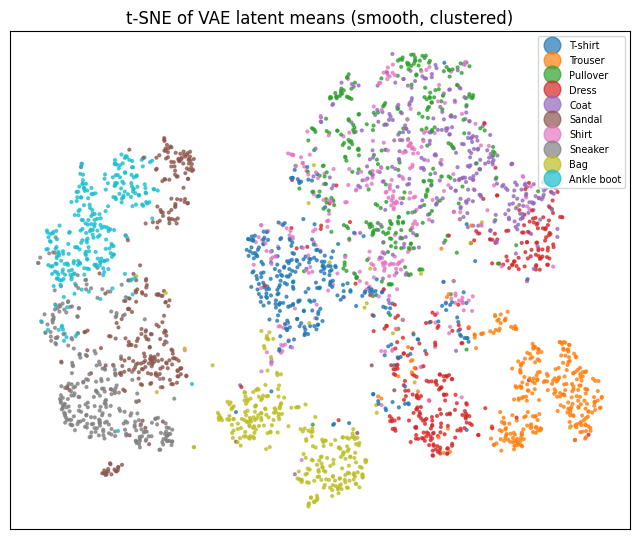

In [13]:
@torch.no_grad()
def get_latents(model, loader, kind="ae", n=3000):
    model.eval()
    zs, ys = [], []
    for x, y in loader:
        x = x.to(device)
        if kind == "ae":
            z = model.encoder(x)
        else:
            mu, _ = model.encoder(x)
            z = mu
        zs.append(z.cpu().numpy()); ys.append(y.numpy())
        if sum(len(a) for a in zs) >= n: break
    Z = np.concatenate(zs)[:n]; Y = np.concatenate(ys)[:n]
    return Z, Y

Z_ae,  Y_ae  = get_latents(ae,  test_loader, "ae",  3000)
Z_vae, Y_vae = get_latents(vae, test_loader, "vae", 3000)

def plot_tsne(Z, Y, title):
    emb = TSNE(n_components=2, perplexity=30, init="pca",
               learning_rate="auto", random_state=42).fit_transform(Z)
    plt.figure(figsize=(6.5, 5.5))
    sc = plt.scatter(emb[:,0], emb[:,1], c=Y, cmap="tab10", s=4, alpha=.7)
    plt.legend(handles=sc.legend_elements()[0], labels=CLASSES,
               fontsize=7, loc="upper right", markerscale=2)
    plt.title(title); plt.xticks([]); plt.yticks([]); plt.tight_layout(); plt.show()

plot_tsne(Z_ae,  Y_ae,  "t-SNE of AE latent codes (deterministic, scattered)")
plot_tsne(Z_vae, Y_vae, "t-SNE of VAE latent means (smooth, clustered)")

4.2 Latent traversal (VAE) — vary one dimension at a time

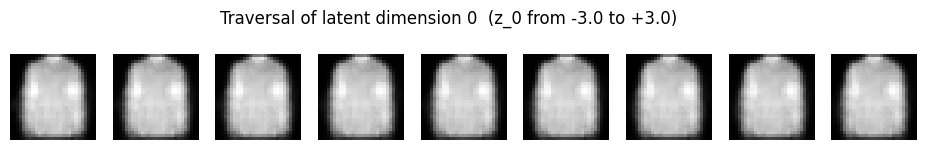

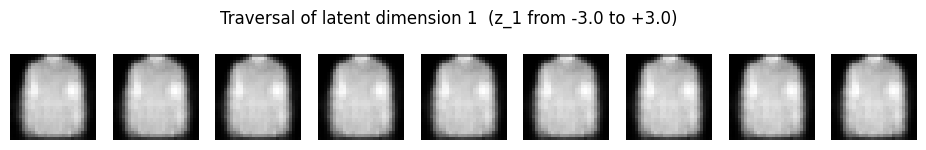

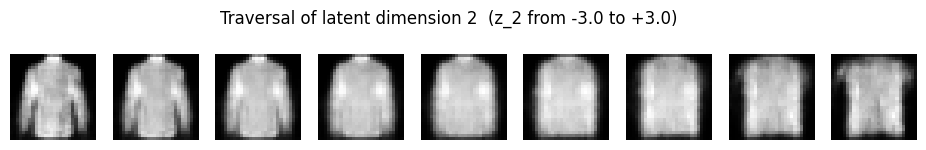

In [22]:
@torch.no_grad()
def latent_traversal(model, dim, n=9, span=3.0):
    model.eval()
    z = torch.zeros(n, model.latent_dim, device=device)
    z[:, dim] = torch.linspace(-span, span, n, device=device)
    imgs = model.decoder(z).cpu()
    fig, ax = plt.subplots(1, n, figsize=(n*1.3, 1.8))
    for i in range(n):
        ax[i].imshow(imgs[i,0], cmap="gray"); ax[i].axis("off")
    plt.suptitle(f"Traversal of latent dimension {dim}  (z_{dim} from -{span} to +{span})")
    plt.show()

for d in [0, 1, 2]:
    latent_traversal(vae, d)

4.3 Interpolation in latent space (AE vs VAE)

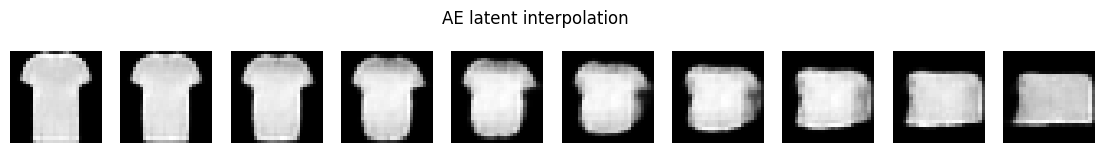

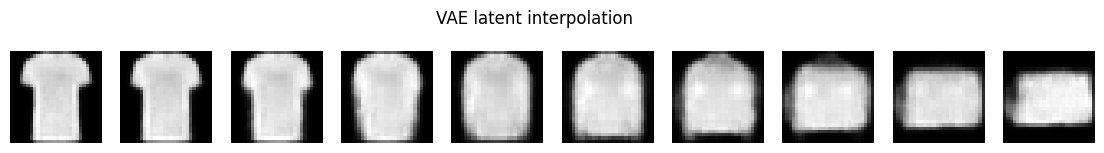

In [23]:
@torch.no_grad()
def interpolate(model, x1, x2, steps=10, kind="ae"):
    model.eval()
    x1 = x1.unsqueeze(0).to(device); x2 = x2.unsqueeze(0).to(device)
    z1 = model.encoder(x1) if kind == "ae" else model.encoder(x1)[0]
    z2 = model.encoder(x2) if kind == "ae" else model.encoder(x2)[0]
    ts = torch.linspace(0, 1, steps, device=device).view(-1, 1)
    z = (1 - ts) * z1 + ts * z2
    out = model.decoder(z).cpu()
    fig, ax = plt.subplots(1, steps, figsize=(steps*1.4, 1.8))
    for i in range(steps):
        ax[i].imshow(out[i,0], cmap="gray"); ax[i].axis("off")
    plt.suptitle(f"{kind.upper()} latent interpolation"); plt.show()

imgs, labels = next(iter(test_loader))
# pick two images of different classes
i1 = int(np.where(labels.numpy() == 0)[0][0])   # T-shirt
i2 = int(np.where(labels.numpy() == 8)[0][0])   # Bag
interpolate(ae,  imgs[i1], imgs[i2], 10, "ae")
interpolate(vae, imgs[i1], imgs[i2], 10, "vae")

5. Comparative Analysis

5.1 Quantitative metrics on the test set

In [24]:
@torch.no_grad()
def evaluate(model, loader, kind="ae", max_batches=None):
    model.eval()
    mse_tot = psnr_tot = ssim_tot = 0.0; n = 0
    for bi, (x, _) in enumerate(loader):
        x = x.to(device)
        out = model(x)[0] if kind == "ae" else model(x)[0]
        b = x.size(0)
        mse = F.mse_loss(out, x, reduction="sum").item() / (b * x.size(1) * x.size(2) * x.size(3))
        mse_tot += mse * b
        psnr_tot += (10 * np.log10(1.0 / max(mse, 1e-12))) * b
        # SSIM on a subset (slow)
        if bi < 4:
            for k in range(min(32, b)):
                ssim_tot += ssim(x[k,0].cpu().numpy(), out[k,0].cpu().numpy(), data_range=1.0)
                n += 1
        if max_batches and bi >= max_batches: break
    N = len(loader.dataset) if not max_batches else (max_batches+1)*loader.batch_size
    return mse_tot / N, psnr_tot / N, ssim_tot / max(n, 1)

ae_mse, ae_psnr, ae_ssim   = evaluate(ae,  test_loader, "ae",  max_batches=10)
vae_mse, vae_psnr, vae_ssim = evaluate(vae, test_loader, "vae", max_batches=10)

# Compression ratio
orig_dim   = 1 * 28 * 28
latent_dim = LATENT_AE
ae_params  = sum(p.numel() for p in ae.parameters())
vae_params = sum(p.numel() for p in vae.parameters())

import pandas as pd
results = pd.DataFrame({
    "Model": ["Autoencoder (AE)", "Variational AE (VAE)"],
    "Latent dim": [LATENT_AE, LATENT_VAE],
    "Parameters": [ae_params, vae_params],
    "Compression ratio (float32)": [f"{orig_dim/latent_dim:.1f}x", f"{orig_dim/LATENT_VAE:.1f}x"],
    "MSE (lower better)": [round(ae_mse, 5), round(vae_mse, 5)],
    "PSNR dB (higher better)": [round(ae_psnr, 2), round(vae_psnr, 2)],
    "SSIM (higher better)": [round(ae_ssim, 4), round(vae_ssim, 4)],
})
results

,Model,Latent dim,Parameters,Compression ratio (float32),MSE (lower better),PSNR dB (higher better),SSIM (higher better)
0,Autoencoder (AE),32,322913,24.5x,0.00710,21.49,0.8217
1,Variational AE (VAE),32,388481,24.5x,0.01978,17.04,0.6248


5.2 Effect of latent dimensionality (AE)

In [25]:
latent_dims = [2, 8, 16, 32, 64]
dim_results = []
for ld in latent_dims:
    m = Autoencoder(ld).to(device)
    h = train_ae(m, train_loader, epochs=8)
    mse, ps, ss = evaluate(m, test_loader, "ae", max_batches=10)
    dim_results.append({"latent_dim": ld, "final_train_loss": round(h[-1],2),
                        "MSE": round(mse,5), "PSNR": round(ps,2), "SSIM": round(ss,4),
                        "compression": f"{orig_dim/ld:.1f}x"})
    print(dim_results[-1])

pd.DataFrame(dim_results)

AE  epoch  1/8  recon_loss=37.1426  (8.9s)
AE  epoch  2/8  recon_loss=26.7322  (9.4s)
AE  epoch  3/8  recon_loss=25.3353  (9.9s)
AE  epoch  4/8  recon_loss=24.4672  (8.6s)
AE  epoch  5/8  recon_loss=23.8268  (9.2s)
AE  epoch  6/8  recon_loss=23.3471  (9.3s)
AE  epoch  7/8  recon_loss=22.9986  (8.7s)
AE  epoch  8/8  recon_loss=22.8008  (9.1s)
{'latent_dim': 2, 'final_train_loss': 22.8, 'MSE': 0.02895, 'PSNR': np.float64(15.39), 'SSIM': np.float64(0.5365), 'compression': '392.0x'}
AE  epoch  1/8  recon_loss=28.8043  (9.3s)
AE  epoch  2/8  recon_loss=14.3285  (9.3s)
AE  epoch  3/8  recon_loss=13.1429  (9.4s)
AE  epoch  4/8  recon_loss=12.5495  (9.4s)
AE  epoch  5/8  recon_loss=12.1570  (9.3s)
AE  epoch  6/8  recon_loss=11.8965  (9.1s)
AE  epoch  7/8  recon_loss=11.7126  (9.5s)
AE  epoch  8/8  recon_loss=11.6024  (9.4s)
{'latent_dim': 8, 'final_train_loss': 11.6, 'MSE': 0.01459, 'PSNR': np.float64(18.36), 'SSIM': np.float64(0.699), 'compression': '98.0x'}
AE  epoch  1/8  recon_loss=22.7969

,latent_dim,final_train_loss,MSE,PSNR,SSIM,compression
0,2,22.80,0.02895,15.39,0.5365,392.0x
1,8,11.60,0.01459,18.36,0.6990,98.0x
2,16,8.40,0.01071,19.71,0.7557,49.0x
3,32,6.53,0.00832,20.81,0.7986,24.5x
4,64,5.61,0.00717,21.45,0.8220,12.2x


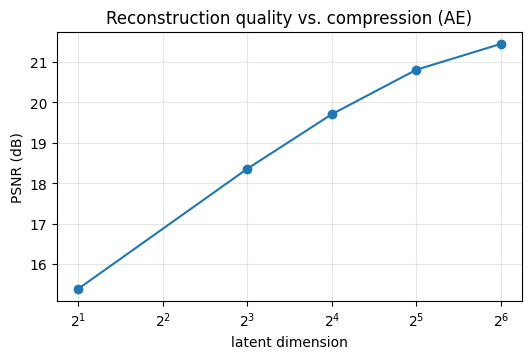

In [26]:
plt.figure(figsize=(6,3.5))
plt.plot([d["latent_dim"] for d in dim_results], [d["PSNR"] for d in dim_results], "o-")
plt.xscale("log", base=2); plt.xlabel("latent dimension"); plt.ylabel("PSNR (dB)")
plt.title("Reconstruction quality vs. compression (AE)"); plt.grid(alpha=.3); plt.show()

5.3 Visual side-by-side comparison

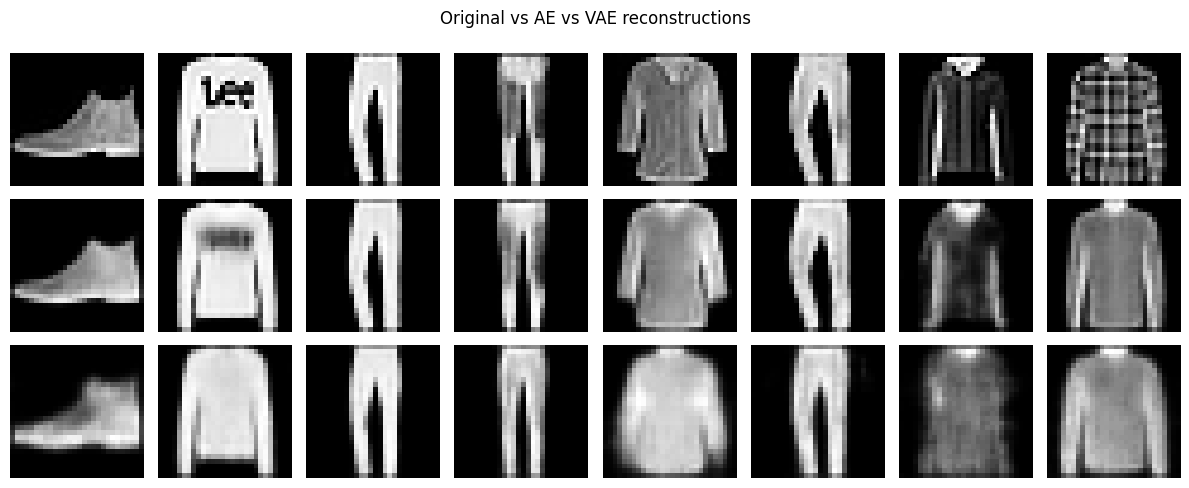

In [27]:
@torch.no_grad()
def compare_all(n=8):
    x, _ = next(iter(test_loader)); x = x[:n].to(device)
    ae_out  = ae(x)[0].cpu()
    vae_out = vae(x)[0].cpu()
    x = x.cpu()
    fig, ax = plt.subplots(3, n, figsize=(n*1.5, 5))
    for i in range(n):
        ax[0,i].imshow(x[i,0], cmap="gray");       ax[0,i].axis("off")
        ax[1,i].imshow(ae_out[i,0], cmap="gray");  ax[1,i].axis("off")
        ax[2,i].imshow(vae_out[i,0], cmap="gray"); ax[2,i].axis("off")
    for r, t in zip(range(3), ["Original", "AE", "VAE"]):
        ax[r,0].set_ylabel(t, fontsize=11)
    plt.suptitle("Original vs AE vs VAE reconstructions"); plt.tight_layout(); plt.show()

compare_all(8)